### 1

Продолжите работу с приложением доставки на дронах. Посчитайте количество сессий на одного пользователя по каждому месяцу, сохраните результат в sessions_per_user['sess_per_user']. Выведитеsessions_per_user на экран.

In [1]:
import pandas as pd

In [5]:
users_data = pd.read_csv('./users_data.csv')

In [7]:
users_data['session_start_ts'] = pd.to_datetime(users_data['session_start_ts'])
users_data['session_end_ts'] = pd.to_datetime(users_data['session_end_ts'])

users_data['session_year']  = users_data['session_start_ts'].dt.year
users_data['session_month'] = users_data['session_start_ts'].dt.month
users_data['session_week']  = users_data['session_start_ts'].dt.isocalendar().week 
users_data['session_date'] = users_data['session_start_ts'].dt.date

In [9]:
sessions_per_user = users_data.groupby(['session_year', 'session_month']).agg({'id': ['count','nunique']})
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sess_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']
print(sessions_per_user) 

                            n_sessions  n_users  sess_per_user
session_year session_month                                    
2018         5                   36716    26975       1.361112
             6                   47607    33473       1.422251
             7                   21586    15839       1.362839


### 2

Найдите продолжительность сессий и постройте гистограмму со 100 корзинами.

In [10]:
users_data['session_start_ts'] = pd.to_datetime(users_data['session_start_ts'], format="%Y-%m-%d %H:%M")
users_data['session_end_ts'] = pd.to_datetime(users_data['session_end_ts'], format="%Y-%m-%d %H:%M")

<Axes: >

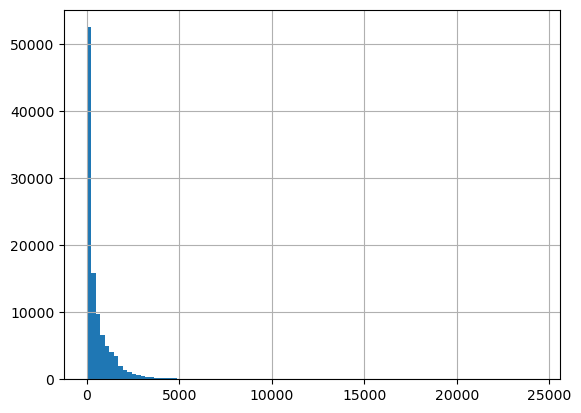

In [11]:
users_data['session_duration_sec'] = (users_data['session_end_ts'] - users_data['session_start_ts']).dt.seconds
users_data['session_duration_sec'].hist(bins=100)

### 3

Найдите значение метрики ASL (средняя продолжительность сессии). Сохраните результат в переменной asl и выведите на экран.

In [12]:
asl = users_data['session_duration_sec'].mode()
asl

0    60
Name: session_duration_sec, dtype: int32